# Chapter 32 Lab — Graph Theory and Network Analysis (Python)

In this lab you will build networks from a **simulated modular functional connectome** and characterize them with graph theory: degree, clustering, path length, betweenness centrality, community detection, modularity, small-worldness — and the single most underappreciated fact in network neuroscience: **every one of these metrics depends on the threshold you chose**.

**How to run this notebook.** It runs directly in your browser (via Pyodide), on Colab, or locally. It uses only `numpy`, `matplotlib`, `networkx`, `pandas`, and `scikit-learn` — all auto-loaded in the browser, no installation needed. It pairs with the [chapter page](../ch32-network-analysis.md), which covers the concepts in depth.

**▶ This notebook is interactive.** Click the **⏻ power icon** at the top right of this page to run it in your browser — no installation needed (the kernel takes ~30–60 s to start the first time). Then run cells **top to bottom**, starting with the first code cell below: later cells depend on the imports and variables defined earlier, and will error if you skip ahead.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

rng = np.random.default_rng(7)

## 1. Simulate a modular functional connectome

We create 30 nodes organized into **three modules** of 10. Each node's time series is a mixture of:

- a **global signal** shared by every node (this weakly links the modules, as global fluctuations do in real fMRI),
- a **module-specific latent signal** (this creates community structure), and
- independent noise.

We then rewire node 0 into a **connector hub**: its time series carries all three module signals equally, so it correlates with every community. Finally, the functional connectome $R$ is the node-by-node correlation matrix — exactly how connectomes are built from real region-level fMRI time series (Chapter 30).

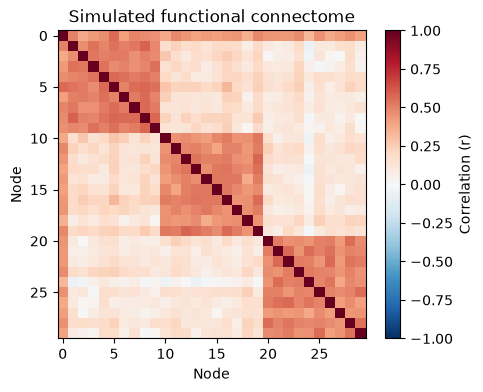

In [2]:
n, T = 30, 200
module = np.repeat([0, 1, 2], 10)              # ground-truth community labels

g = rng.standard_normal(T)                     # shared global signal
signals = rng.standard_normal((3, T))          # one latent signal per module

ts = 0.8 * g + signals[module] + 1.2 * rng.standard_normal((n, T))

# Plant a connector hub at node 0: equal parts of all three module signals
ts[0] = 0.8 * g + signals.sum(axis=0) / np.sqrt(3) + 0.6 * rng.standard_normal(T)

R = np.corrcoef(ts)                            # 30 x 30 functional connectome

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(R, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set(title="Simulated functional connectome", xlabel="Node", ylabel="Node")
fig.colorbar(im, label="Correlation (r)")
plt.show()

The block-diagonal structure is the community structure: within-module correlations are strong (~0.5), between-module correlations weak (~0.2, from the shared global signal). Row/column 0 — the connector hub — is correlated with *all* modules.

## 2. Threshold, binarize, and build the graph

Graph metrics generally require sparse graphs, so we **threshold** the connectome (keep edges with $r > 0.3$) and **binarize** it into an adjacency matrix $A$. The **connection density** — surviving edges divided by all possible edges $N(N-1)/2$ — measures how sparse the result is. Remember this number: everything downstream depends on it.

Edges: 156 of 435 possible -> density = 0.36


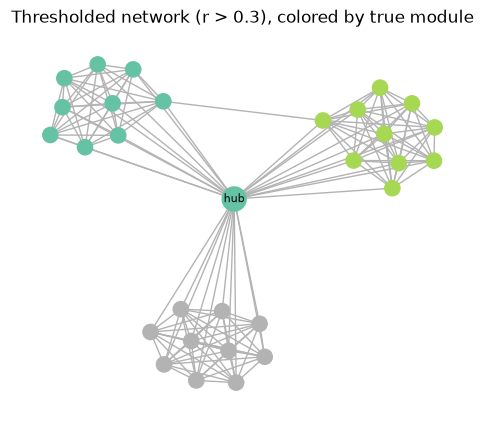

In [3]:
thr0 = 0.3
A = (R > thr0).astype(int)
np.fill_diagonal(A, 0)                         # no self-loops
G = nx.from_numpy_array(A)

n_possible = n * (n - 1) // 2
density = nx.density(G)
print(f"Edges: {G.number_of_edges()} of {n_possible} possible -> density = {density:.2f}")

pos = nx.spring_layout(G, seed=3)
fig, ax = plt.subplots(figsize=(6, 5))
node_size = [300 if i == 0 else 120 for i in G.nodes]
nx.draw_networkx(G, pos, ax=ax, node_color=module, cmap="Set2",
                 node_size=node_size, with_labels=False, edge_color="0.7")
nx.draw_networkx_labels(G, pos, labels={0: "hub"}, font_size=8, ax=ax)
ax.set_title("Thresholded network (r > 0.3), colored by true module")
ax.axis("off")
plt.show()

Three dense clusters, a handful of between-module edges, and node 0 sitting between the communities.

## 3. Local metrics: degree, clustering, betweenness — find the hubs

- **Degree** $k_i = \sum_{j \neq i} a_{ij}$ counts a node's neighbors — the most common index of centrality and "hub status."
- **Clustering coefficient** $C_i = 2t_i / (k_i(k_i-1))$ is the fraction of a node's neighbor pairs that are themselves connected (closed triangles). High for nodes buried inside a dense module.
- **Betweenness centrality** is the fraction of all shortest paths that pass through a node. Connector hubs that *bridge* modules score high — even a hub with modest degree can be the network's critical bottleneck.

In [4]:
degree = dict(G.degree())
clustering = nx.clustering(G)
betweenness = nx.betweenness_centrality(G)

metrics = pd.DataFrame({
    "module": module,
    "degree": pd.Series(degree),
    "clustering": pd.Series(clustering),
    "betweenness": pd.Series(betweenness),
})
print("Top 5 nodes by betweenness centrality:")
print(metrics.sort_values("betweenness", ascending=False).head(5).round(3))

Top 5 nodes by betweenness centrality:
    module  degree  clustering  betweenness
0        0      29       0.313        0.666
16       1      11       0.836        0.011
5        0      10       0.822        0.010
28       2      10       1.000        0.000
27       2      10       1.000        0.000


The planted connector hub (node 0) tops the betweenness ranking: because it links all three modules, a large share of shortest paths between communities run through it. Note its clustering coefficient is comparatively *low* — its neighbors live in different modules and are rarely connected to each other. That combination (high betweenness, low clustering) is the signature of a **connector hub**; a **provincial hub** would instead show high degree *within* one densely-clustered module.

## 4. Global metrics: segregation and integration

- The **network clustering coefficient** $C = \frac{1}{N}\sum_i C_i$ indexes *functional segregation* — specialized processing within densely interconnected groups.
- The **characteristic path length** $L = \frac{1}{N}\sum_i L_i$ (average shortest path between all node pairs) indexes *functional integration* — how quickly information can be combined across the network. When the graph is disconnected, we compute it on the largest connected component.
- **Global efficiency** is the average of $1/d_{ij}$, which handles disconnected pairs gracefully (their contribution is 0).

In [5]:
C = nx.average_clustering(G)

Gcc = G.subgraph(max(nx.connected_components(G), key=len))
L = nx.average_shortest_path_length(Gcc)

E_glob = nx.global_efficiency(G)

print(f"Clustering coefficient C = {C:.2f}")
print(f"Characteristic path length L = {L:.2f} "
      f"(on largest component, {Gcc.number_of_nodes()}/{n} nodes)")
print(f"Global efficiency = {E_glob:.2f}")

Clustering coefficient C = 0.97
Characteristic path length L = 1.64 (on largest component, 30/30 nodes)
Global efficiency = 0.68


## 5. Small-worldness: compare against random null networks

Is this network *small-world* — more clustered than a random network, but with a similarly short path length? The test requires **null networks matched on size and density**: we generate random (Erdős–Rényi-style) graphs with the same number of nodes and edges, and compute

$$\sigma = \frac{C / C_{rand}}{L / L_{rand}},$$

with $\sigma > 1$ the conventional cutoff. This is the same logic used for any test of non-random network structure: simulate many random graphs matched on density and connectedness, and compare the observed metric to that null distribution.

In [6]:
n_rand = 20
m = G.number_of_edges()
C_rand, L_rand = [], []
for seed in range(n_rand):
    Gr = nx.gnm_random_graph(n, m, seed=seed)   # same nodes, same # edges
    C_rand.append(nx.average_clustering(Gr))
    Grc = Gr.subgraph(max(nx.connected_components(Gr), key=len))
    L_rand.append(nx.average_shortest_path_length(Grc))

C_ratio = C / np.mean(C_rand)
L_ratio = L / np.mean(L_rand)
sigma = C_ratio / L_ratio
print(f"C / C_rand = {C_ratio:.2f}   (clustering vs. random)")
print(f"L / L_rand = {L_ratio:.2f}   (path length vs. random)")
print(f"sigma = {sigma:.2f}  -> {'small-world' if sigma > 1 else 'not small-world'}")

C / C_rand = 2.69   (clustering vs. random)
L / L_rand = 0.99   (path length vs. random)
sigma = 2.71  -> small-world


The modular network is several times more clustered than random graphs of the same density, while its path length is only slightly longer — the small-world combination of high segregation *and* high integration that brains are thought to optimize (at minimal wiring cost).

## 6. Community detection and modularity

Communities (modules) are groups of nodes more densely connected to each other than to the rest of the network. We detect them with **greedy modularity optimization** (Clauset–Newman–Moore), which maximizes Newman's modularity $Q$ — the fraction of edges falling within communities, minus what would be expected by chance. We then check the detected partition against the ground-truth module labels we built into the simulation.

Detected 3 communities, modularity Q = 0.53
Adjusted Rand index vs. ground truth = 1.00 (1 = perfect recovery)

Detected community x true module cross-tabulation:
true module   0   1   2
detected               
0            10   0   0
1             0  10   0
2             0   0  10


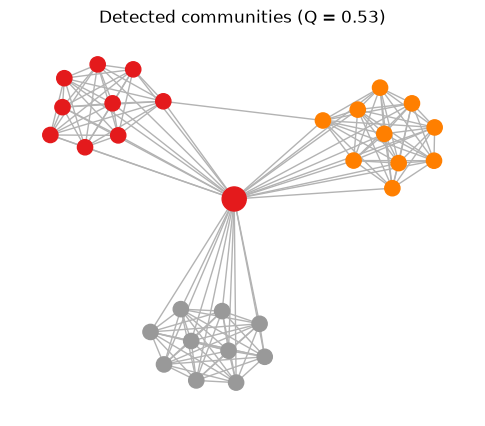

In [7]:
from sklearn.metrics import adjusted_rand_score

communities = nx.community.greedy_modularity_communities(G)
Q = nx.community.modularity(G, communities)

detected = np.zeros(n, dtype=int)
for c, members in enumerate(communities):
    for node in members:
        detected[node] = c

ari = adjusted_rand_score(module, detected)
print(f"Detected {len(communities)} communities, modularity Q = {Q:.2f}")
print(f"Adjusted Rand index vs. ground truth = {ari:.2f} (1 = perfect recovery)")
print("\nDetected community x true module cross-tabulation:")
print(pd.crosstab(pd.Series(detected, name="detected"),
                  pd.Series(module, name="true module")))

fig, ax = plt.subplots(figsize=(6, 5))
nx.draw_networkx(G, pos, ax=ax, node_color=detected, cmap="Set1",
                 node_size=node_size, with_labels=False, edge_color="0.7")
ax.set_title(f"Detected communities (Q = {Q:.2f})")
ax.axis("off")
plt.show()

The algorithm recovers the planted three-module structure essentially perfectly. Keep in mind, though: community detection algorithms will partition *any* network, including a random one — a meaningful $Q$ should be benchmarked against the $Q$ obtained from matched random graphs.

## 7. The threshold changes everything

Now the cautionary tale. We sweep the correlation threshold from 0.10 to 0.50 and recompute density, clustering, and path length at each value. Watch all three move together.

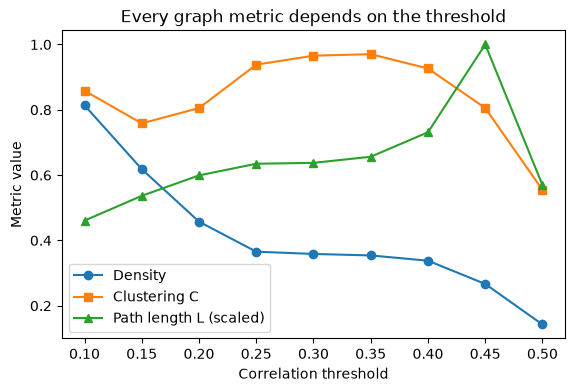

In [8]:
thresholds = np.arange(0.10, 0.51, 0.05)

def graph_metrics(Rmat, thr):
    Ai = (Rmat > thr).astype(int)
    np.fill_diagonal(Ai, 0)
    Gi = nx.from_numpy_array(Ai)
    dens = nx.density(Gi)
    Ci = nx.average_clustering(Gi)
    Gic = Gi.subgraph(max(nx.connected_components(Gi), key=len))
    Li = (nx.average_shortest_path_length(Gic)
          if Gic.number_of_nodes() > 1 else np.nan)
    return dens, Ci, Li

sweep = np.array([graph_metrics(R, t) for t in thresholds])

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(thresholds, sweep[:, 0], "-o", label="Density")
ax.plot(thresholds, sweep[:, 1], "-s", label="Clustering C")
ax.plot(thresholds, sweep[:, 2] / np.nanmax(sweep[:, 2]), "-^",
        label="Path length L (scaled)")
ax.set(xlabel="Correlation threshold", ylabel="Metric value",
       title="Every graph metric depends on the threshold")
ax.legend()
plt.show()

There is no threshold at which the metrics are "correct" — each threshold yields a different network, and density, clustering, and path length co-vary across the sweep. A reported clustering coefficient means little without the density it was computed at. Good practice is to report metrics across a *range* of thresholds or densities, or integrate over them.

## 8. Density-matched comparison of two "subjects"

Here is where threshold choice becomes a scientific problem, not just a nuisance. **Subject B** below has *exactly the same network architecture* as Subject A — same modules, same connector hub — but weaker overall connectivity (more measurement noise, as might arise from head motion or scanner differences).

At a **fixed correlation threshold**, Subject B's graph comes out much sparser — and every metric differs, a spurious "topological group difference." Matching **density** instead (keeping the same fraction of strongest edges for both subjects) makes the comparison fair.

In [9]:
# Subject B: same architecture, noisier data (globally weaker correlations)
tsB = 0.8 * g + signals[module] + 2.0 * rng.standard_normal((n, T))
tsB[0] = 0.8 * g + signals.sum(axis=0) / np.sqrt(3) + 1.2 * rng.standard_normal(T)
RB = np.corrcoef(tsB)

def binarize_at_density(Rmat, target_density):
    """Keep the strongest edges so that density matches target_density."""
    iu = np.triu_indices_from(Rmat, k=1)
    vals = np.sort(Rmat[iu])[::-1]
    n_keep = int(round(target_density * len(vals)))
    thr = vals[n_keep - 1]
    Ai = (Rmat >= thr).astype(int)
    np.fill_diagonal(Ai, 0)
    return Ai

rows = []
for name, Rmat in [("Subject A", R), ("Subject B (noisier)", RB)]:
    # Fixed threshold r > 0.3
    Af = (Rmat > 0.3).astype(int); np.fill_diagonal(Af, 0)
    Gf = nx.from_numpy_array(Af)
    # Density-matched at 20%
    Am = binarize_at_density(Rmat, 0.20)
    Gm = nx.from_numpy_array(Am)
    rows.append({
        "subject": name,
        "density @ r>0.3": nx.density(Gf),
        "C @ r>0.3": nx.average_clustering(Gf),
        "density matched": nx.density(Gm),
        "C matched": nx.average_clustering(Gm),
    })

print(pd.DataFrame(rows).set_index("subject").round(2))

                     density @ r>0.3  C @ r>0.3  density matched  C matched
subject                                                                    
Subject A                       0.36       0.97              0.2       0.67
Subject B (noisier)             0.08       0.32              0.2       0.52


At the fixed threshold, Subject B looks sparser *and* less clustered — but nothing about B's network organization actually differs; only the signal-to-noise ratio does. After density matching, the density confound is gone and the clustering gap shrinks dramatically; the residual difference reflects only noise-driven errors in which edges rank strongest, not any real difference in architecture. In group studies, the same logic motivates fixing the number of edges (or density) per subject, sweeping densities, and testing group differences with permutation tests.

## Wrap-up

- A functional connectome becomes a graph by thresholding/binarizing; **density** describes the result and silently drives every downstream metric.
- **Local** metrics (degree, clustering, betweenness) find hubs; high betweenness with low clustering marks a **connector hub**.
- **Global** metrics capture segregation ($C$) and integration ($L$, efficiency); **small-worldness** $\sigma > 1$ requires density-matched random nulls.
- **Greedy modularity optimization** recovers planted communities and quantifies their strength with $Q$.
- Group comparisons at a fixed threshold confound topology with connectivity strength — **match densities** and use permutation tests.

Return to the [chapter page](../ch32-network-analysis.md) for the thought questions and quiz.